In [19]:
!pip install opencv-python opencv-contrib-python matplotlib numpy scipy -q


In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os
import warnings
warnings.filterwarnings('ignore')

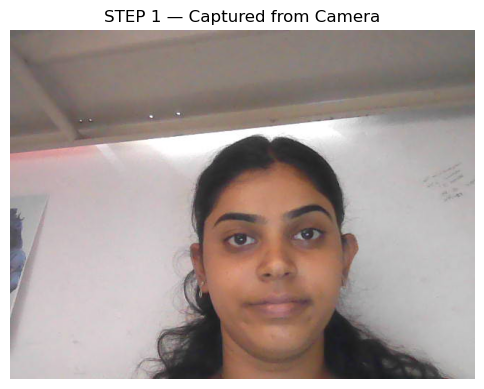

Image shape: 640x480


In [29]:
cap = cv2.VideoCapture(0)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Camera not found or cannot be opened.")

img_bgr = frame.copy()
cv2.imwrite("face.jpg", img_bgr)
H, W = img_bgr.shape[:2]

plt.figure(figsize=(6, 5))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("STEP 1 — Captured from Camera")
plt.axis('off')
plt.show()
print(f"Image shape: {W}x{H}")

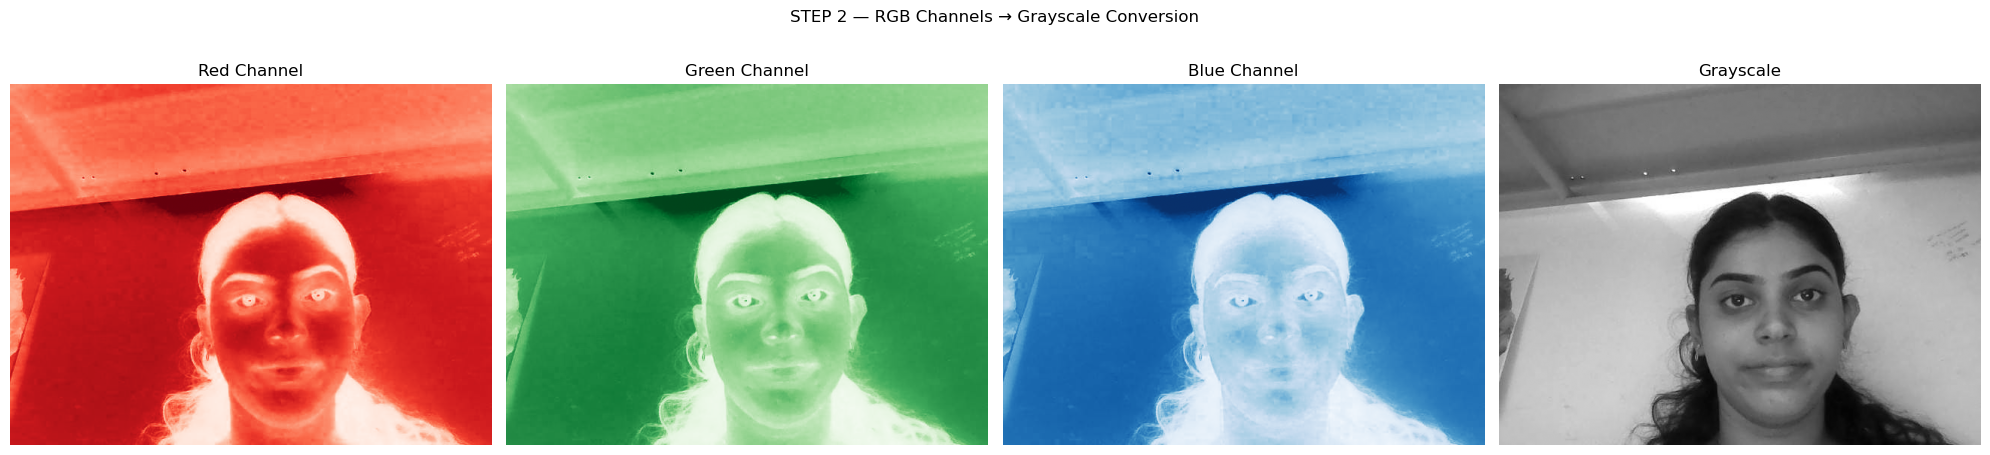

In [30]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
R, G, B = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("STEP 2 — RGB Channels → Grayscale Conversion")
axes[0].imshow(R, cmap='Reds');    axes[0].set_title("Red Channel")
axes[1].imshow(G, cmap='Greens');  axes[1].set_title("Green Channel")
axes[2].imshow(B, cmap='Blues');   axes[2].set_title("Blue Channel")
axes[3].imshow(gray, cmap='gray'); axes[3].set_title("Grayscale")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

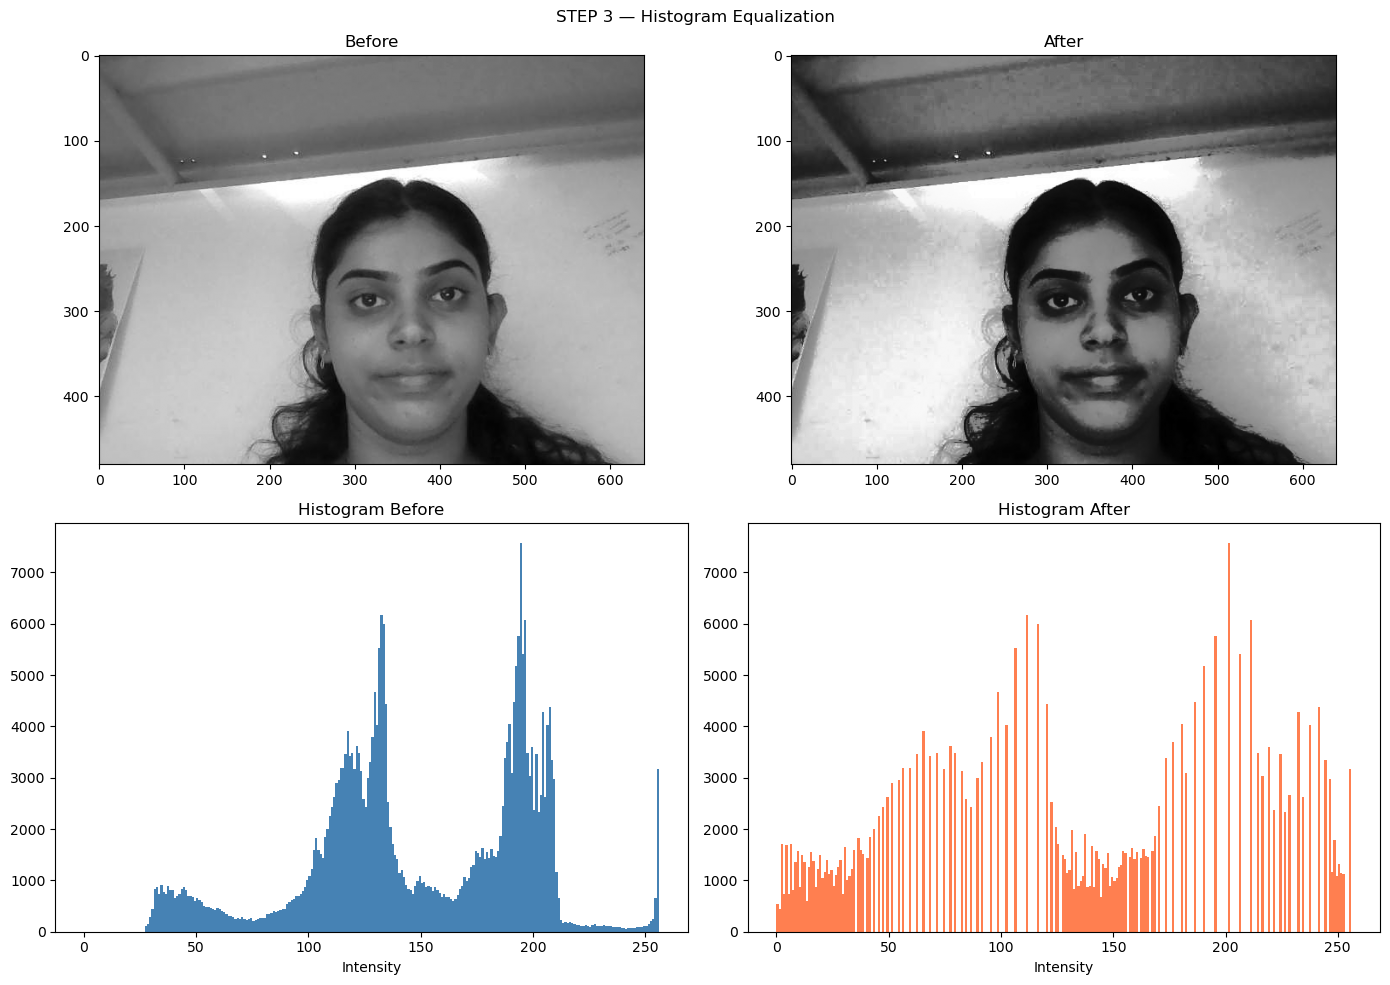

In [31]:
gray_eq = cv2.equalizeHist(gray)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("STEP 3 — Histogram Equalization")
axes[0,0].imshow(gray, cmap='gray');    axes[0,0].set_title("Before")
axes[0,1].imshow(gray_eq, cmap='gray'); axes[0,1].set_title("After")
axes[1,0].hist(gray.ravel(),    256, [0,256], color='steelblue')
axes[1,0].set_title("Histogram Before"); axes[1,0].set_xlabel("Intensity")
axes[1,1].hist(gray_eq.ravel(), 256, [0,256], color='coral')
axes[1,1].set_title("Histogram After");  axes[1,1].set_xlabel("Intensity")
plt.tight_layout()
plt.show()

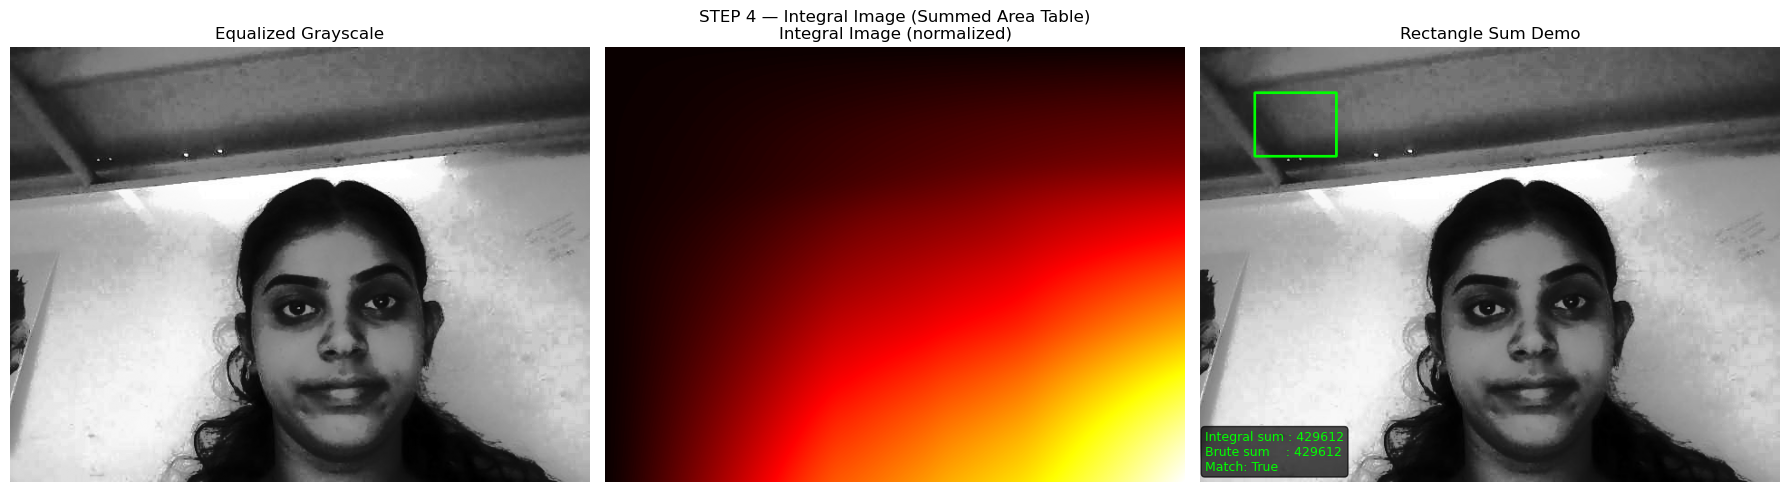

In [32]:
integral = cv2.integral(gray_eq)
integral_norm = cv2.normalize(integral, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def rect_sum(ii, r1, c1, r2, c2):
    return ii[r2, c2] - ii[r1, c2] - ii[r2, c1] + ii[r1, c1]

r1, c1, r2, c2 = 50, 60, 120, 150
rect_s  = rect_sum(integral, r1, c1, r2, c2)
brute_s = int(gray_eq[r1:r2, c1:c2].sum())

demo = cv2.cvtColor(gray_eq, cv2.COLOR_GRAY2BGR)
cv2.rectangle(demo, (c1, r1), (c2, r2), (0, 255, 0), 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("STEP 4 — Integral Image (Summed Area Table)")
axes[0].imshow(gray_eq, cmap='gray');       axes[0].set_title("Equalized Grayscale")
axes[1].imshow(integral_norm, cmap='hot');  axes[1].set_title("Integral Image (normalized)")
axes[2].imshow(cv2.cvtColor(demo, cv2.COLOR_BGR2RGB))
axes[2].set_title("Rectangle Sum Demo")
axes[2].text(5, gray_eq.shape[0]-10,
    f"Integral sum : {rect_s}\nBrute sum    : {brute_s}\nMatch: {rect_s==brute_s}",
    fontsize=9, color='lime', verticalalignment='bottom',
    bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

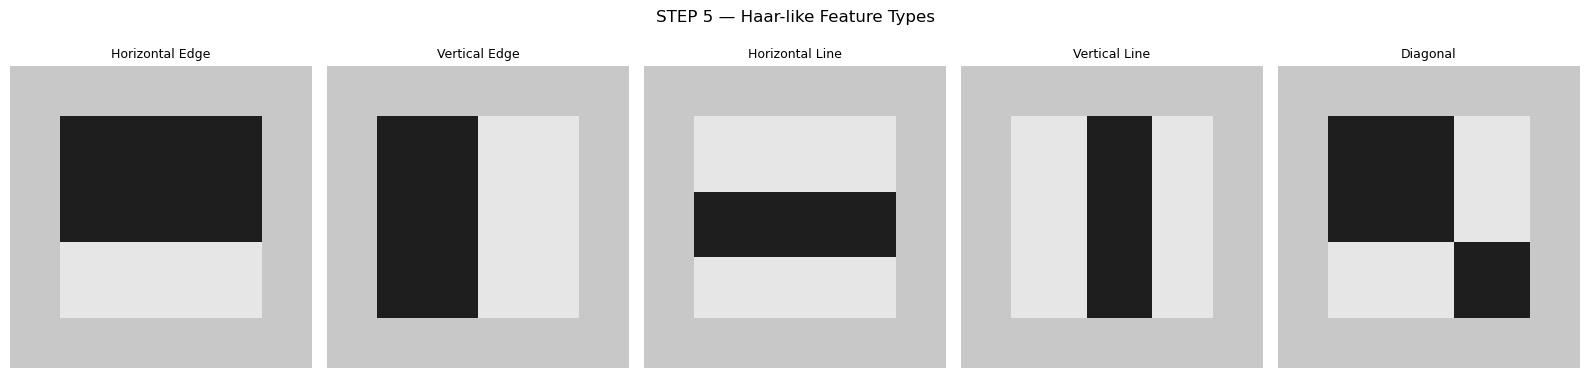

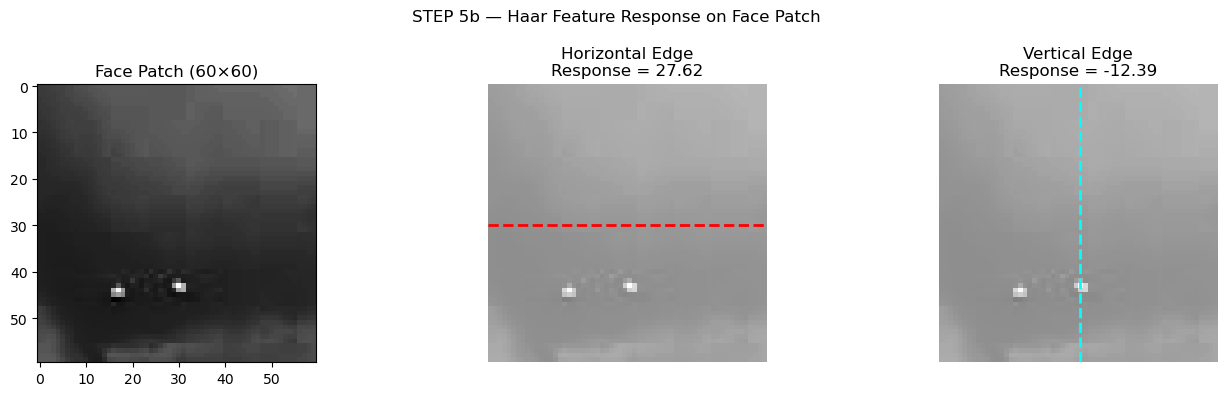

In [33]:
def draw_haar(ax, feat_type, title):
    c = np.ones((60, 60, 3), dtype=np.uint8) * 200
    if feat_type == 'edge_h':
        c[10:35, 10:50] = 30;  c[35:50, 10:50] = 230
    elif feat_type == 'edge_v':
        c[10:50, 10:30] = 30;  c[10:50, 30:50] = 230
    elif feat_type == 'line_h':
        c[10:25, 10:50] = 230; c[25:38, 10:50] = 30;  c[38:50, 10:50] = 230
    elif feat_type == 'line_v':
        c[10:50, 10:25] = 230; c[10:50, 25:38] = 30;  c[10:50, 38:50] = 230
    elif feat_type == 'diagonal':
        c[10:35, 10:35] = 30;  c[35:50, 35:50] = 30
        c[10:35, 35:50] = 230; c[35:50, 10:35] = 230
    ax.imshow(c); ax.set_title(title, fontsize=9); ax.axis('off')

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle("STEP 5 — Haar-like Feature Types")
types  = ['edge_h', 'edge_v', 'line_h', 'line_v', 'diagonal']
labels = ['Horizontal Edge', 'Vertical Edge', 'Horizontal Line', 'Vertical Line', 'Diagonal']
for ax, t, l in zip(axes, types, labels):
    draw_haar(ax, t, l)
plt.tight_layout()
plt.show()

patch = gray_eq[80:140, 80:140]
half  = patch.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("STEP 5b — Haar Feature Response on Face Patch")
axes[0].imshow(patch, cmap='gray'); axes[0].set_title("Face Patch (60×60)")

axes[1].imshow(patch, cmap='gray', alpha=0.5)
axes[1].axhline(half, color='red', linewidth=2, linestyle='--')
h_resp = patch[:half,:].mean() - patch[half:,:].mean()
axes[1].set_title(f"Horizontal Edge\nResponse = {h_resp:.2f}"); axes[1].axis('off')

axes[2].imshow(patch, cmap='gray', alpha=0.5)
axes[2].axvline(half, color='cyan', linewidth=2, linestyle='--')
v_resp = patch[:,:half].mean() - patch[:,half:].mean()
axes[2].set_title(f"Vertical Edge\nResponse = {v_resp:.2f}"); axes[2].axis('off')

plt.tight_layout()
plt.show()

Pyramid levels: 12
  Level 0: 640×480
  Level 1: 492×369
  Level 2: 378×283
  Level 3: 290×217
  Level 4: 223×166
  Level 5: 171×127
  Level 6: 131×97
  Level 7: 100×74
  Level 8: 76×56
  Level 9: 58×43
  Level 10: 44×33
  Level 11: 33×25


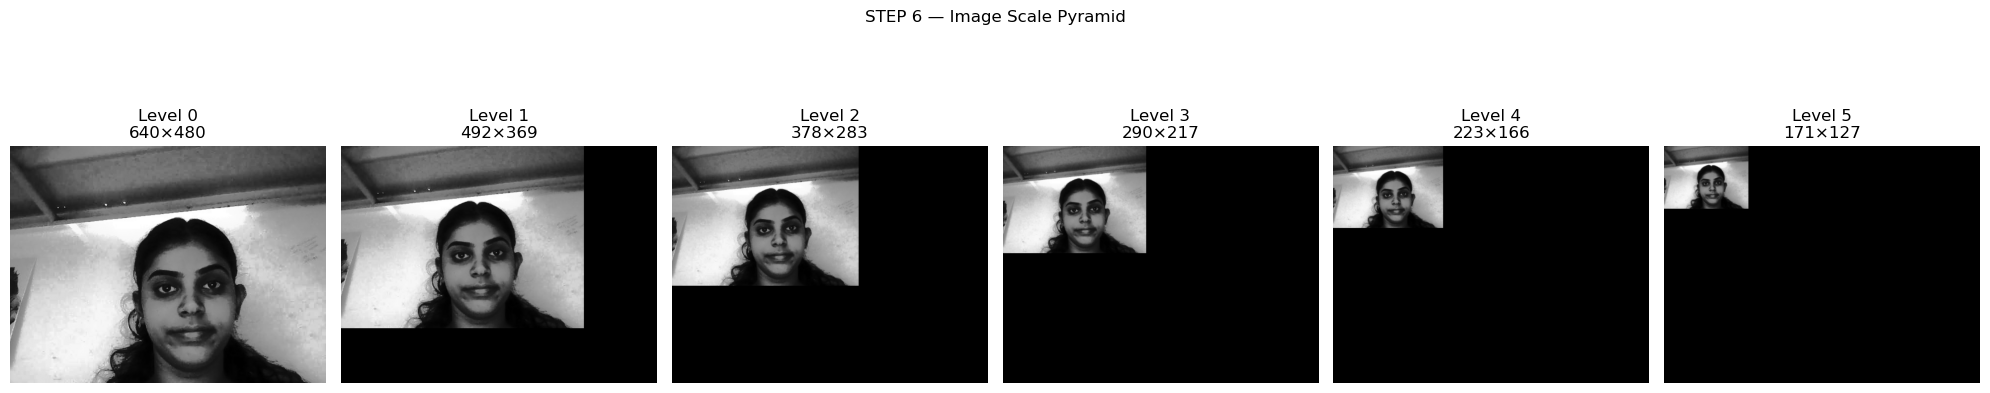

In [34]:
def build_pyramid(img, scale=1.3, min_size=24):
    pyramid, cur = [], img.copy()
    while min(cur.shape[:2]) >= min_size:
        pyramid.append(cur.copy())
        nw, nh = int(cur.shape[1]/scale), int(cur.shape[0]/scale)
        if nw < min_size or nh < min_size: break
        cur = cv2.resize(cur, (nw, nh))
    return pyramid

pyramid = build_pyramid(gray_eq)
print(f"Pyramid levels: {len(pyramid)}")
for i, l in enumerate(pyramid):
    print(f"  Level {i}: {l.shape[1]}×{l.shape[0]}")

n = min(6, len(pyramid))
fig, axes = plt.subplots(1, n, figsize=(20, 5))
fig.suptitle("STEP 6 — Image Scale Pyramid")
for i in range(n):
    canvas = np.zeros_like(gray_eq)
    lvl = pyramid[i]
    canvas[:lvl.shape[0], :lvl.shape[1]] = lvl
    axes[i].imshow(canvas, cmap='gray')
    axes[i].set_title(f"Level {i}\n{lvl.shape[1]}×{lvl.shape[0]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

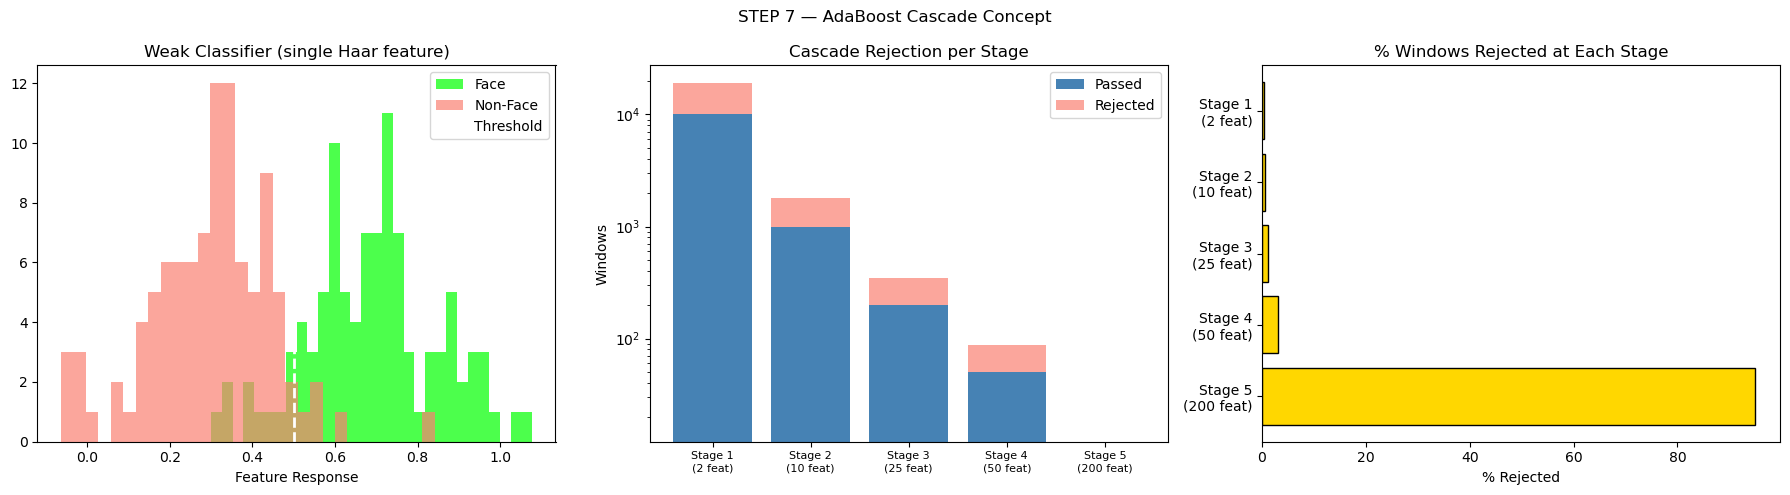

In [35]:
face_scores    = np.random.normal(0.7, 0.15, 100)
nonface_scores = np.random.normal(0.3, 0.15, 100)
stages  = ['Stage 1\n(2 feat)', 'Stage 2\n(10 feat)', 'Stage 3\n(25 feat)', 'Stage 4\n(50 feat)', 'Stage 5\n(200 feat)']
passed  = [10000, 1000, 200, 50, 12]
rejected = [10000-1000, 1000-200, 200-50, 50-12, 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("STEP 7 — AdaBoost Cascade Concept")

axes[0].hist(face_scores,    30, alpha=0.7, color='lime',   label='Face')
axes[0].hist(nonface_scores, 30, alpha=0.7, color='salmon', label='Non-Face')
axes[0].axvline(0.5, color='white', linestyle='--', linewidth=2, label='Threshold')
axes[0].set_title("Weak Classifier (single Haar feature)")
axes[0].set_xlabel("Feature Response"); axes[0].legend()

x = np.arange(len(stages))
axes[1].bar(x, passed,    color='steelblue', label='Passed')
axes[1].bar(x, rejected,  bottom=passed, color='salmon', alpha=0.7, label='Rejected')
axes[1].set_xticks(x); axes[1].set_xticklabels(stages, fontsize=8)
axes[1].set_title("Cascade Rejection per Stage")
axes[1].set_ylabel("Windows"); axes[1].legend(); axes[1].set_yscale('log')

axes[2].barh(stages[::-1], [95, 3, 1.2, 0.5, 0.3], color='gold', edgecolor='black')
axes[2].set_title("% Windows Rejected at Each Stage")
axes[2].set_xlabel("% Rejected")

plt.tight_layout()
plt.show()

In [36]:
CASCADE_FILES = {
    "face":    "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml",
    "eye":     "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_eye.xml",
    "smile":   "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_smile.xml",
}
for name, url in CASCADE_FILES.items():
    fname = f"haarcascade_{name}.xml"
    if not os.path.exists(fname):
        urllib.request.urlretrieve(url, fname)
    print(f"✅ {fname}")

face_cascade  = cv2.CascadeClassifier("haarcascade_face.xml")
eye_cascade   = cv2.CascadeClassifier("haarcascade_eye.xml")
smile_cascade = cv2.CascadeClassifier("haarcascade_smile.xml")

✅ haarcascade_face.xml
✅ haarcascade_eye.xml
✅ haarcascade_smile.xml


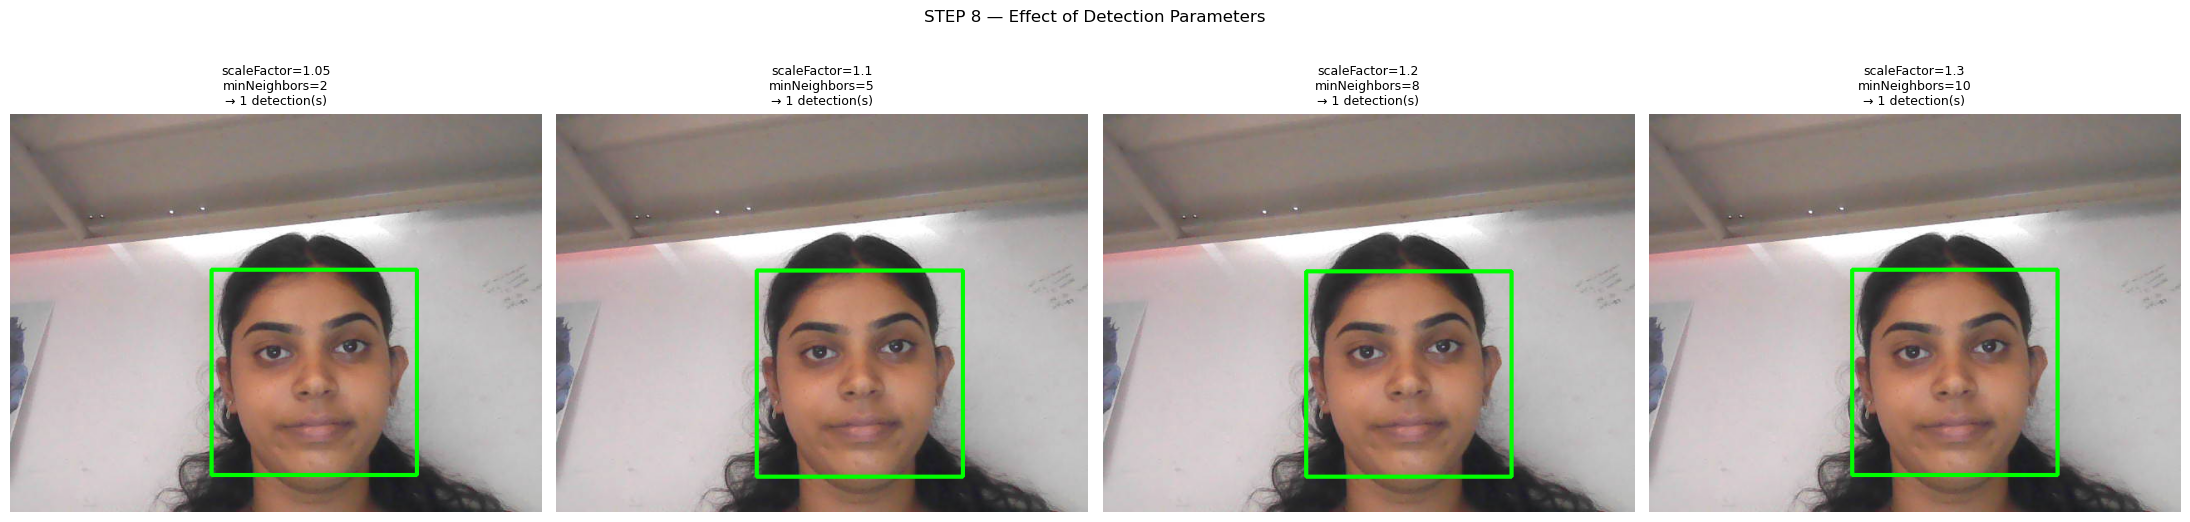

In [37]:
configs = [
    (1.05, 2,  "scaleFactor=1.05\nminNeighbors=2"),
    (1.1,  5,  "scaleFactor=1.1\nminNeighbors=5"),
    (1.2,  8,  "scaleFactor=1.2\nminNeighbors=8"),
    (1.3,  10, "scaleFactor=1.3\nminNeighbors=10"),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle("STEP 8 — Effect of Detection Parameters")

for ax, (sf, nb, title) in zip(axes, configs):
    faces = face_cascade.detectMultiScale(gray_eq, scaleFactor=sf, minNeighbors=nb,
                                          minSize=(30,30), flags=cv2.CASCADE_SCALE_IMAGE)
    canvas = img_bgr.copy()
    for (x, y, w, h) in (faces if len(faces) > 0 else []):
        cv2.rectangle(canvas, (x,y), (x+w, y+h), (0,255,0), 3)
    ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{title}\n→ {len(faces) if len(faces)>0 else 0} detection(s)", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

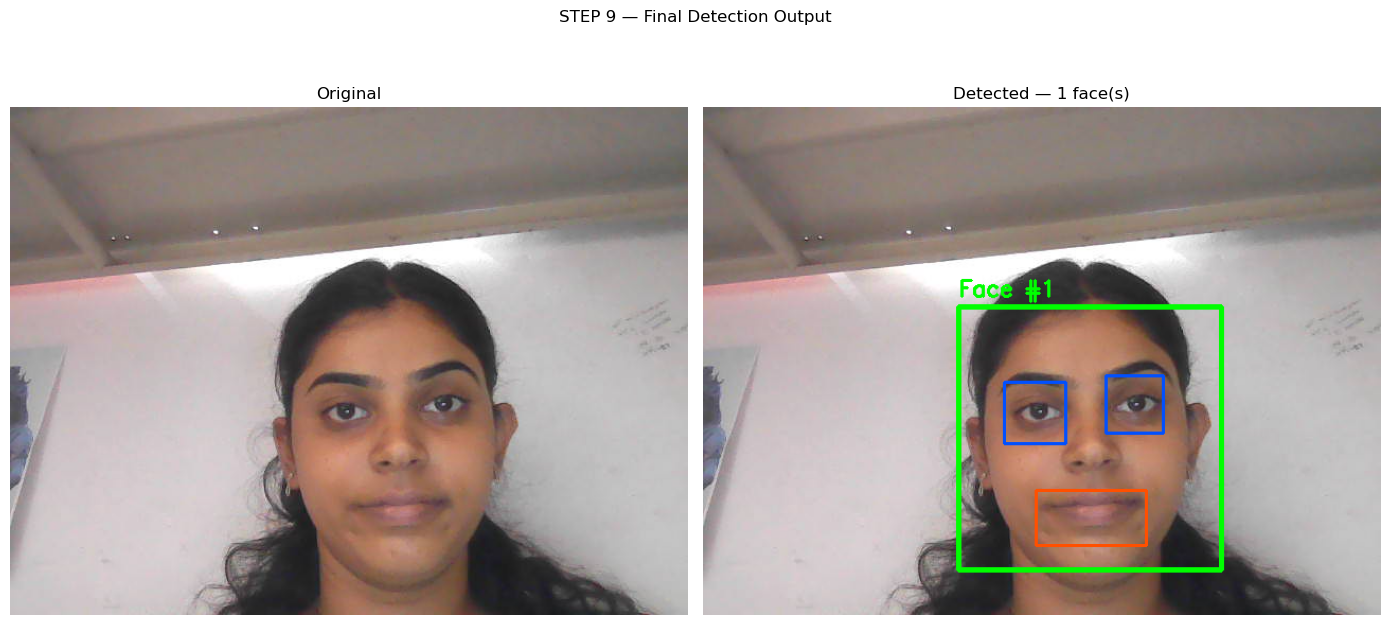

In [38]:
faces = face_cascade.detectMultiScale(gray_eq, scaleFactor=1.1, minNeighbors=5,
                                       minSize=(30,30), flags=cv2.CASCADE_SCALE_IMAGE)
result = img_bgr.copy()

for i, (x, y, w, h) in enumerate(faces if len(faces) > 0 else []):
    cv2.rectangle(result, (x,y), (x+w, y+h), (0,255,0), 3)
    cv2.putText(result, f"Face #{i+1}", (x, max(y-10,15)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)
    roi_gray = gray_eq[y:y+h, x:x+w]
    roi_col  = result[y:y+h, x:x+w]
    for (ex,ey,ew,eh) in eye_cascade.detectMultiScale(roi_gray, 1.1, 10, minSize=(15,15)):
        cv2.rectangle(roi_col, (ex,ey), (ex+ew,ey+eh), (255,80,0), 2)
    for (sx,sy,sw,sh) in smile_cascade.detectMultiScale(roi_gray, 1.7, 22, minSize=(25,15)):
        cv2.rectangle(roi_col, (sx,sy), (sx+sw,sy+sh), (0,80,255), 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle("STEP 9 — Final Detection Output")
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB));   axes[0].set_title("Original")
axes[1].imshow(cv2.cvtColor(result,  cv2.COLOR_BGR2RGB));   axes[1].set_title(f"Detected — {len(faces) if len(faces)>0 else 0} face(s)")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

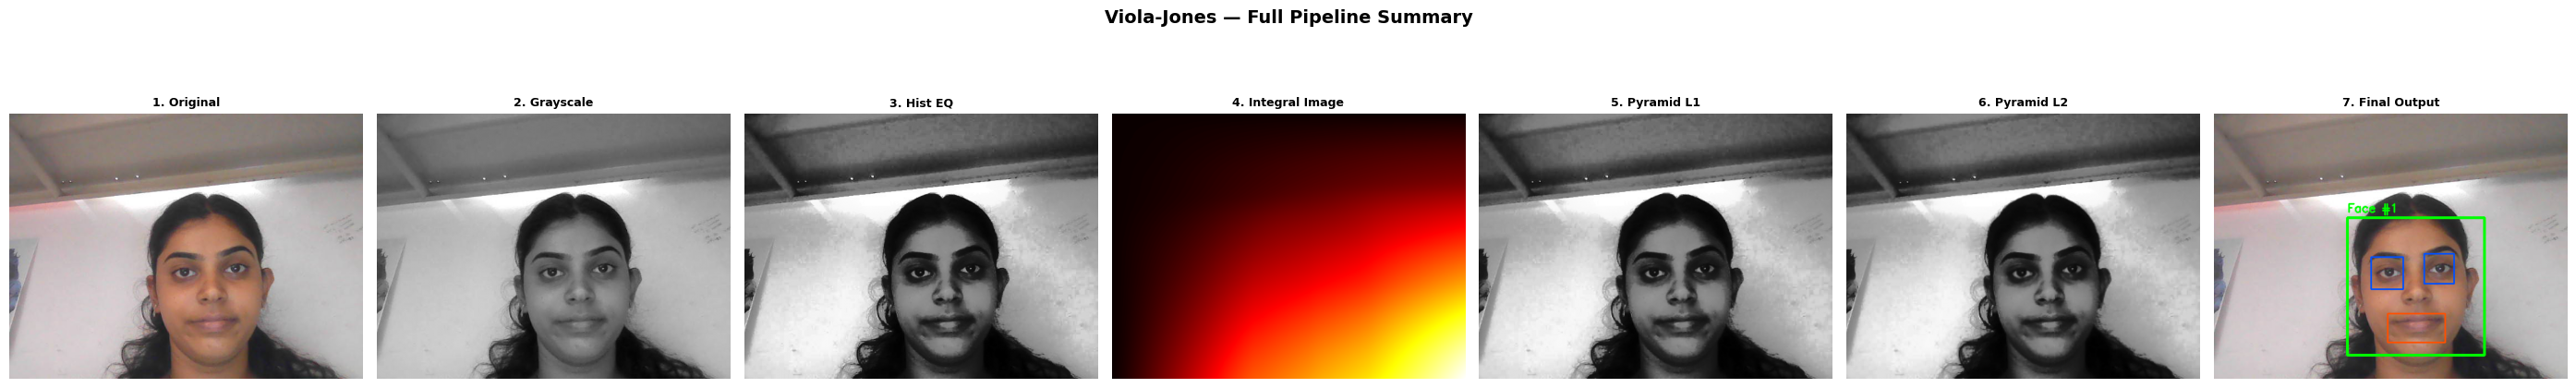

In [39]:
steps_imgs = [
    (cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB),                                              None,   "1. Original"),
    (gray,                                                                                    'gray', "2. Grayscale"),
    (gray_eq,                                                                                 'gray', "3. Hist EQ"),
    (cv2.normalize(cv2.integral(gray_eq),None,0,255,cv2.NORM_MINMAX).astype(np.uint8),      'hot',  "4. Integral Image"),
    (pyramid[1] if len(pyramid)>1 else pyramid[0],                                           'gray', "5. Pyramid L1"),
    (pyramid[2] if len(pyramid)>2 else pyramid[0],                                           'gray', "6. Pyramid L2"),
    (cv2.cvtColor(result, cv2.COLOR_BGR2RGB),                                                None,   "7. Final Output"),
]

fig, axes = plt.subplots(1, 7, figsize=(28, 5))
fig.suptitle("Viola-Jones — Full Pipeline Summary", fontsize=14, fontweight='bold')
for ax, (img_data, cmap, title) in zip(axes, steps_imgs):
    ax.imshow(img_data, cmap=cmap)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()